____
# Lagrangian spectra along the trajectories


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance_groupby, compute_variance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [2]:
def generate_0_15m_coloc_dataframe(freq_band):
    
    DT = 12
    
    # SURFACE
    base_dic = dict(dt='12h', 
            drifter_preprocess = 'spectral_decomp',
            drifter_preprocess_param= freq_band,
            alti_product_key='swot2km',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '0')
    
    
    comb_list = [base_dic]
    
    
    ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
    ds0 = ds0.where(ds0.depth==0, drop=True)
    #distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
    #ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
    #ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    #ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
    #ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)
    
    df0 = ds0.to_dataframe().reset_index().set_index('row_number')
    
    #DEPTH 15M
    base_dic = dict(dt='12h', 
                drifter_preprocess = 'spectral_decomp',
                drifter_preprocess_param=freq_band,
                alti_product_key='swot2km',
                alti_diff_method = 'fromduacsv',
                alti_diff_method_param = '',
                ggd_var = 'fromduacsv',
                wd_product_key = 'era5', 
                wd_model ='rio', 
                wd_depth = '15')
    
    comb_list = [    
        base_dic, 
    ]
    
    ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
    ds15 =ds15.where(ds15.depth==15, drop=True)
    #distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
    #ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
    ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    #ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
    #ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)
    
    df15 = ds15.to_dataframe().reset_index().set_index('row_number')

    return df0, df15

def filter_traj(ds, T=20, cutoff = { 'HF':[2.2, 70.95], 'LF': [0.88], 'inertial':[1.05, 1.75], 'diurnal' : [0.88, 1.05], 'semidiurnal':[1.9, 2.1],}):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize
    
    # coefficients
    dt = 1/24/6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False


    # filter
    dss = ds.fillna(0)
    for c in cutoff : 
        if c == 'LF' : pass_zero = True
        #elif c == 'HF' : pass_zero = 'highpass'
        else : pass_zero = False
        for v in ['acce', 'accn', 'core', 'corn', 'ggde', 'ggdn', 'wde', 'wdn'] :
            taps = signal.firwin(numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True)
            dss[c+v] = xr.DataArray(
                filtfilt(taps, 1, dss[v]),
                dims=[ "datetime"],
                )
            dss[c+v] = xr.DataArray(
                filtfilt(taps, 1, dss[v]),
                dims=["datetime"],
                )
    
    return dss

# Data : SWOT- 2km fromduacs

In [95]:
df0, df15 = generate_0_15m_coloc_dataframe('')

# Xarray format 
D = []
def coloc_dataset(df):
    D = []
    for id_ in df.drifter_id.unique():
        df_ = df[df.drifter_id==id_].drop_duplicates('datetime').set_index('datetime')
        ds_ = df_.to_xarray().sortby('datetime')
        ds_['drifter_id'] = ds_['drifter_id'].values[0]
        ds_ = ds_.set_coords('drifter_id').expand_dims('drifter_id')
        D.append(ds_)
    ds = xr.concat(D, dim='drifter_id')
    ds = ds.interp(datetime = pd.date_range(ds.datetime.min().values, ds.datetime.max().values, freq='10min'))
    return ds

ds0 = coloc_dataset(df0)
ds15 = coloc_dataset(df15)

321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


# Spectra 

In [97]:
var = ['acc', 'cor', 'ggd', 'wd']
from cstes import U
from sstats import tseries as ts
rename_forspectra = {'datetime':'time', 'drifter_id':'id'}
def spectrum_ds(ds, nperseg="10D", detrend=False, vc = [("acce", "accn"), ("core", "corn"), ("ggde", "ggdn"), ("wde", "wdn")]):
    ds = ds.rename(rename_forspectra)
    #ds = df.reset_index().set_index(["time", "id"]).to_xarray()
    E = []
    for tup in vc:
        ds_ = ds.fillna(0).ts.spectrum(unit="1D", nperseg=nperseg, detrend=detrend, complex=tup)
        E.append(ds_)
    return xr.merge(E)
dss0 = spectrum_ds(ds0.fillna(0)[[v +'e' for v in var] + [v +'n' for v in var]]/U, nperseg="20D", detrend=False)
dss15 = spectrum_ds(ds15.fillna(0)[[v +'e' for v in var] + [v +'n' for v in var]]/U, nperseg="20D", detrend=False)

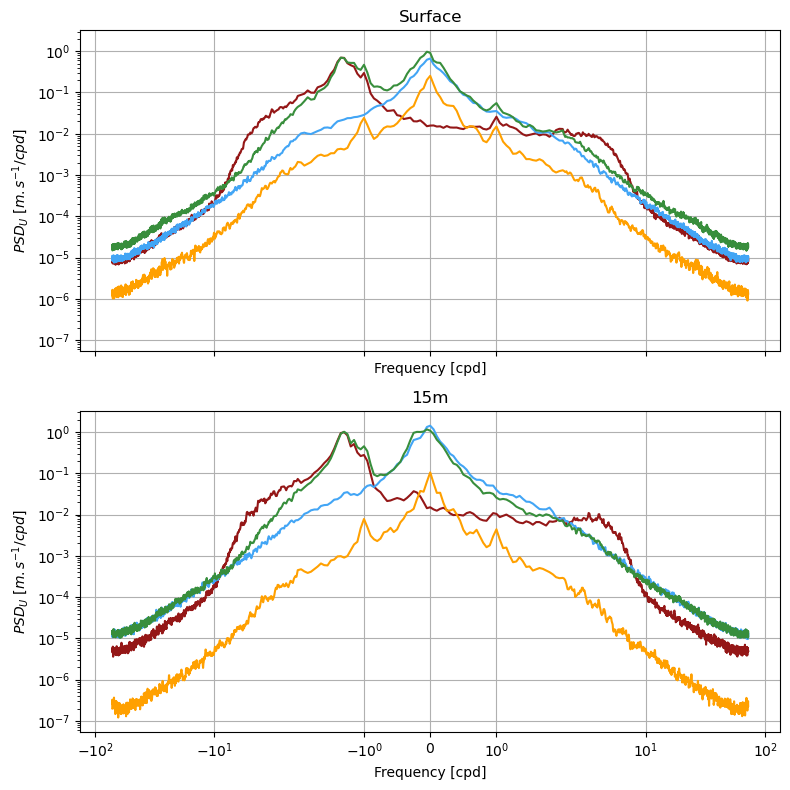

In [100]:
linthresh = 1e-1
linscale = 0.3
fig, axs = plt.subplots(2, 1, figsize=(8, 8), frameon=False, sharex=True, sharey=True)

ax=axs[0]
dss0.acce_accn.mean("id").plot(ax=ax,label = 'Lagrangian acceleration', c=c0['acc'])
dss0.ggde_ggdn.mean("id").plot(ax=ax,label ='Pressure gradient term', c=c0['ggd'])
dss0.core_corn.mean("id").plot(ax=ax,label ='Coriolis acceleration', c=c0['cor'])
dss0.wde_wdn.mean("id").plot(ax=ax,label ='Wind term', c=c0['wd'])
ax.set_title('Surface')


ax=axs[1]
dss15.acce_accn.mean("id").plot(ax=ax,label = 'Lagrangian acceleration', c=c0['acc'])
dss15.ggde_ggdn.mean("id").plot(ax=ax,label ='Pressure gradient term', c=c0['ggd'])
dss15.core_corn.mean("id").plot(ax=ax,label ='Coriolis acceleration', c=c0['cor'])
dss15.wde_wdn.mean("id").plot(ax=ax,label ='Wind term', c=c0['wd'])
ax.set_title('15m')

for ax in axs :
    ax.set_xscale("symlog")  # , linthresh=linthresh, linscale=linscale)
    ax.set_yscale("log")
    ax.grid()
    ax.set_ylabel(r"$PSD_U$ $[m.s^{-1}/cpd]$")
    ax.set_xlabel("Frequency [cpd]")

fig.tight_layout()

In [101]:
def negpos_spectra(ds, freqkey="frequency"):
    """Return two datasets with cyclonic/anticyclonic spectra"""
    ds_inv = ds.sortby(freqkey, ascending=False)
    dsneg = ds_inv.where(ds_inv[freqkey] <= 0, drop=True)
    dsneg[freqkey] = -dsneg[freqkey]
    dspos = ds.where(ds[freqkey] >= 0, drop=True)
    return dsneg, dspos

dss0 = sum(negpos_spectra(dss0, freqkey="frequency"))
dss15 = sum(negpos_spectra(dss15, freqkey="frequency"))

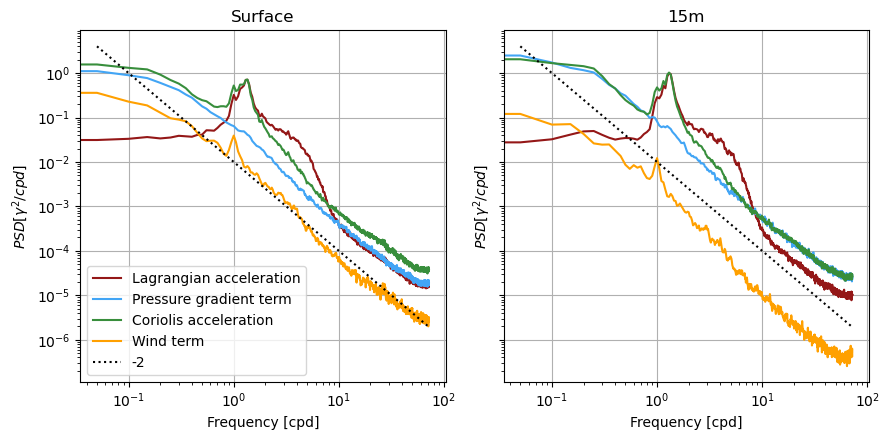

In [114]:
linthresh = 1e-1
linscale = 0.3
fig, axs = plt.subplots(1, 2, figsize=(9, 4.5), frameon=False, sharex=True, sharey=True)

i=0
for dss in [dss0, dss15] :
    ax=axs[i]
    dss.acce_accn.mean("id").plot(ax=ax,label = 'Lagrangian acceleration', c=c0['acc'])
    dss.ggde_ggdn.mean("id").plot(ax=ax,label ='Pressure gradient term', c=c0['ggd'])
    dss.core_corn.mean("id").plot(ax=ax,label ='Coriolis acceleration', c=c0['cor'])
    dss.wde_wdn.mean("id").plot(ax=ax,label ='Wind term', c=c0['wd'])
    ax.plot(dss.frequency, dss.frequency**(-2)*1e-2, ls=':', c='k', label='-2')
    i+=1
    
axs[0].set_title('Surface')    
axs[1].set_title('15m')   

for ax in axs :
    ax.set_ylabel(r"$PSD [\gamma^2/cpd]$")
    ax.set_xlabel("Frequency [cpd]")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid()
axs[0].legend(loc='lower left')
    
fig.tight_layout()